**Q2.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly skewed variables that require a log or arcsinh transformation) Note this is different than normalizing: there is a text below that explains further. Clean the data however you think is most appropriate.

In [3]:
# Load data
df = pd.read_csv("cars_hw.csv", index_col=0)

# Transform skewed numerical variables
df['Price'] = np.log1p(df['Price']) # log transform Price
df['Mileage_Run'] = np.log1p(df['Mileage_Run']) # log transform Mileage

print(df.head())

         Make  Make_Year   Color  Body_Type  Mileage_Run No_of_Owners  \
1  Volkswagen       2017  silver      sedan    10.705758          1st   
2     Hyundai       2016     red  crossover     9.918672          1st   
3       Honda       2019   white        suv    10.293534          2nd   
4     Renault       2017  bronze  hatchback    10.482374          1st   
5     Hyundai       2017  orange  hatchback    10.131698          1st   

   Seating_Capacity Fuel_Type Transmission Transmission_Type      Price  
1                 5    diesel      7-Speed         Automatic  13.395441  
2                 5    petrol      5-Speed            Manual  13.432786  
3                 5    petrol      5-Speed            Manual  13.583580  
4                 5    petrol      5-Speed            Manual  12.933624  
5                 5    petrol      5-Speed            Manual  13.151924  


2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?

count    976.000000
mean      13.411035
std        0.450275
min       12.144203
25%       13.072649
50%       13.409797
75%       13.691082
max       14.894261
Name: Price, dtype: float64


/tmp/ipykernel_104921/2724299747.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['Price'], shade=True, color='orange')


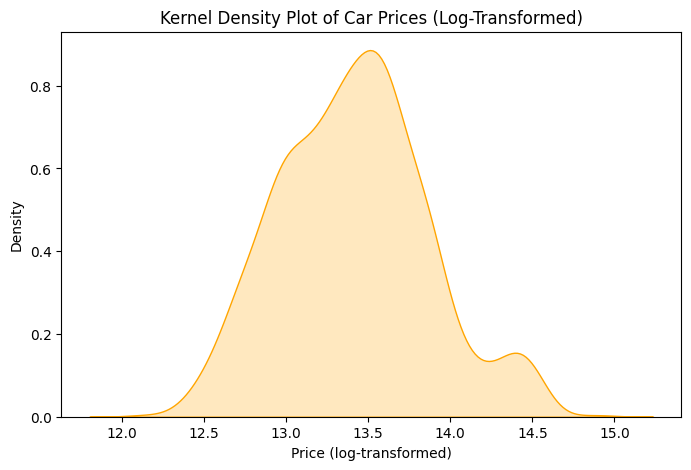

               count       mean       std        min        25%        50%  \
Make                                                                         
Chevrolet        6.0  12.919898  0.480974  12.495008  12.568395  12.752289   
Datsun           3.0  12.576050  0.036311  12.538971  12.558305  12.577640   
Ford            52.0  13.468282  0.210894  12.577640  13.361382  13.469494   
Honda           73.0  13.536319  0.336971  12.663501  13.272508  13.573440   
Hyundai        305.0  13.368512  0.398781  12.421188  13.091906  13.366095   
Jeep             4.0  14.216591  0.105084  14.070154  14.183271  14.240266   
Kia              8.0  14.292178  0.076877  14.129592  14.272242  14.303106   
MG Motors       35.0  14.439052  0.066263  14.278616  14.395745  14.429615   
Mahindra        18.0  13.898954  0.159906  13.587356  13.851809  13.905681   
Maruti Suzuki  293.0  13.218134  0.371408  12.375820  12.926351  13.174958   
Nissan           4.0  13.641195  0.392609  13.071072  13.537776 

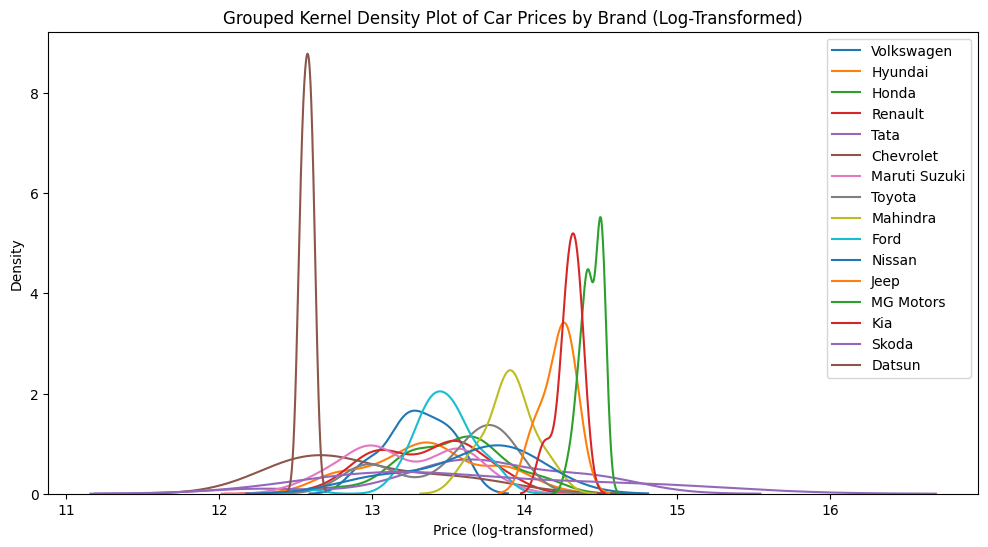

In [4]:
# Summarize the Price variable
print(df['Price'].describe())

# Kernel density plot of Price
plt.figure(figsize=(8,5))
sns.kdeplot(df['Price'], shade=True, color='orange')
plt.title('Kernel Density Plot of Car Prices (Log-Transformed)')
plt.xlabel('Price (log-transformed)')
plt.show()

# Summarize prices by car brand
price_by_make = df.groupby('Make')['Price'].describe()
print(price_by_make)

# Grouped kernel density plot by Make
plt.figure(figsize=(12,6))
for make in df['Make'].unique():
    subset = df[df['Make'] == make]
    sns.kdeplot(subset['Price'], label=make)
plt.title('Grouped Kernel Density Plot of Car Prices by Brand (Log-Transformed)')
plt.xlabel('Price (log-transformed)')
plt.ylabel('Density')
plt.legend()
plt.show()

# The most expensive car brands are MG Motors, Kia, and Jeep.
# In general, the overall price distribution (log-transformed) has a mean of 13.41, with a roughly bell-shaped distribution.

3. Split the data into an 80% training set and a 20% testing set.

In [5]:
# Split data into train/test
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?

In [6]:
# Identify numeric and categorical columns
numeric_cols = ['Make_Year', 'Mileage_Run', 'Seating_Capacity']
cat_cols = ['Make', 'Color', 'Body_Type', 'Fuel_Type', 'Transmission', 'Transmission_Type', 'No_of_Owners']

# Split features and target
X_train_num = train_df[numeric_cols]
X_test_num = test_df[numeric_cols]
y_train = train_df['Price']
y_test = test_df['Price']

# Numeric-only model
num_model = LinearRegression()
num_model.fit(X_train_num, y_train)

# Numeric predictions
y_train_pred_num = num_model.predict(X_train_num)
y_test_pred_num = num_model.predict(X_test_num)

# Numeric metrics
r2_train_num = num_model.score(X_train_num, y_train)
r2_test_num = num_model.score(X_test_num, y_test)
rmse_train_num = np.sqrt(mean_squared_error(y_train, y_train_pred_num))
rmse_test_num = np.sqrt(mean_squared_error(y_test, y_test_pred_num))

print("Numeric-only model:")
print("R^2 (train):", r2_train_num, "RMSE (train):", rmse_train_num)
print("R^2 (test):", r2_test_num, "RMSE (test):", rmse_test_num)
print("----------------------------------------------------")

# Categorical-only model (use one-hot encoding)
X_train_cat = pd.get_dummies(train_df[cat_cols], drop_first=True)
X_test_cat = pd.get_dummies(test_df[cat_cols], drop_first=True)

# Align test columns with train columns
X_test_cat = X_test_cat.reindex(columns=X_train_cat.columns, fill_value=0)

cat_model = LinearRegression()
cat_model.fit(X_train_cat, y_train)

# Categorical predictions and metrics
y_test_pred_cat = cat_model.predict(X_test_cat)
r2_test_cat = cat_model.score(X_test_cat, y_test)
rmse_test_cat = np.sqrt(mean_squared_error(y_test, y_test_pred_cat))

print("Categorical-only model:")
print("R^2 (test):", r2_test_cat, "RMSE (test):", rmse_test_cat)
print("----------------------------------------------------")

# Combined model (numeric + categorical)
X_train_all = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_all = pd.concat([X_test_num, X_test_cat], axis=1)

combined_model = LinearRegression()
combined_model.fit(X_train_all, y_train)

# Combined predictions and metrics
y_test_pred_all = combined_model.predict(X_test_all)
r2_test_all = combined_model.score(X_test_all, y_test)
rmse_test_all = np.sqrt(mean_squared_error(y_test, y_test_pred_all))

print("Combined model (all variables):")
print("R^2 (test):", r2_test_all, "RMSE (test):", rmse_test_all)

# The categorical-only model performs better than the numeric-only model on the test set (R^2 = 0.654 vs 0.400, RMSE = 0.257 vs 0.338)
# The joint model performs better than either alone. Compared to the categorical-only model, R^2 increases by ~0.16 (0.814 - 0.654) and RMSE decreases by ~0.07 (0.257 - 0.188)

Numeric-only model:
R^2 (train): 0.42483642143874734 RMSE (train): 0.3435315412138305
R^2 (test): 0.4000197175768122 RMSE (test): 0.3382571859337909
----------------------------------------------------
Categorical-only model:
R^2 (test): 0.653504693768878 RMSE (test): 0.2570556893247232
----------------------------------------------------
Combined model (all variables):
R^2 (test): 0.8138794887238094 RMSE (test): 0.18839772792915563


5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?

In [7]:
# Store results for each polynomial degree
poly_results = []

# Test polynomial degrees from 1 (linear) to 5
for degree in range(1, 6):
    # Create polynomial features
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_num)
    X_test_poly = poly.transform(X_test_num)
    
    # Fit linear regression on expanded features
    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, y_train)
    
    # Predict on train and test
    y_train_pred = poly_model.predict(X_train_poly)
    y_test_pred = poly_model.predict(X_test_poly)
    
    # Compute metrics
    r2_train = poly_model.score(X_train_poly, y_train)
    r2_test = poly_model.score(X_test_poly, y_test)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    # Store results
    poly_results.append({
        'degree': degree,
        'r2_train': r2_train,
        'r2_test': r2_test,
        'rmse_train': rmse_train,
        'rmse_test': rmse_test
    })

# Convert results to DataFrame
poly_results_df = pd.DataFrame(poly_results)
print(poly_results_df)

# As you increase the degree of the expansion, train R^2 slightly increases, test R^2 fluctuates, train RMSE slightly decreases, and test RMSE fluctuates.
# In this output, R^2 never goes negative.
# My best model with expanded features is degree 2, because it has the highest test R^2 (0.418) and lowest test RMSE (0.333).
# Compared to my best model from part 4 (combined numeric + categorical model), it still has a much weaker R^2 and RMSE.

   degree  r2_train   r2_test  rmse_train  rmse_test
0       1  0.424836  0.400020    0.343532   0.338257
1       2  0.454075  0.417596    0.334686   0.333266
2       3  0.458167  0.409444    0.333429   0.335590
3       4  0.459392  0.407078    0.333052   0.336262
4       5  0.459416  0.407122    0.333045   0.336249


6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

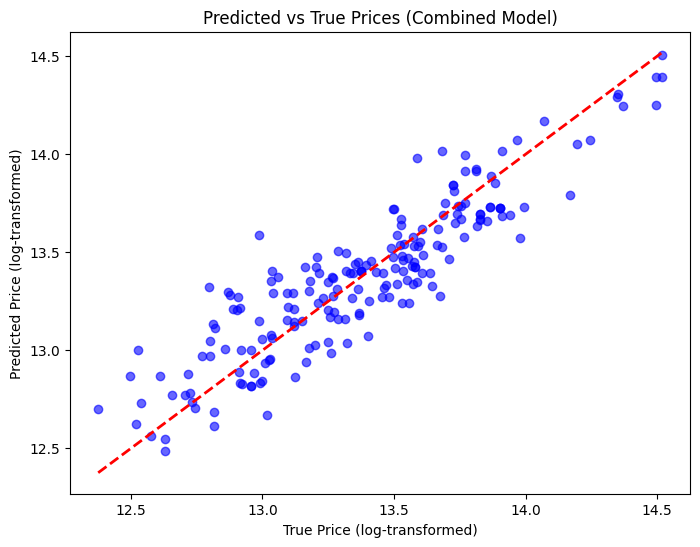

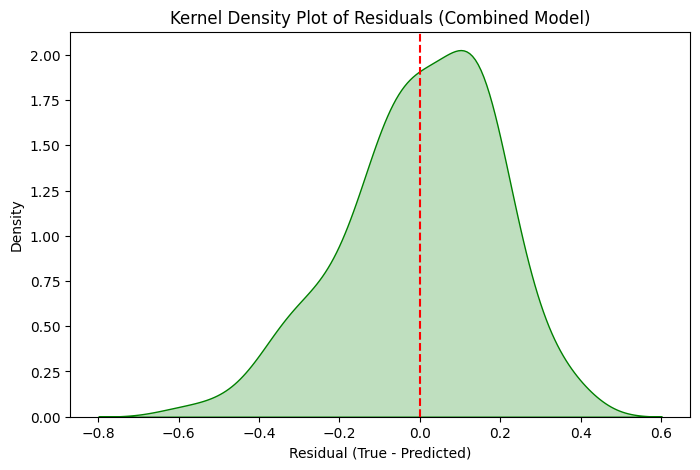

In [8]:
# Predicted values on the test set (combined numeric + categorical model)
y_pred = combined_model.predict(X_test_all)

# Scatter plot: predicted vs true values
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # diagonal line
plt.xlabel("True Price (log-transformed)")
plt.ylabel("Predicted Price (log-transformed)")
plt.title("Predicted vs True Prices (Combined Model)")
plt.show()

# Compute residuals
residuals = y_test - y_pred

# Kernel density plot of residuals
plt.figure(figsize=(8,5))
sns.kdeplot(residuals, fill=True, color='green')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Residual (True - Predicted)")
plt.ylabel("Density")
plt.title("Kernel Density Plot of Residuals (Combined Model)")
plt.show()

# The predicted and true values do roughly line up along the diagonal for plot 1. 
# The residuals do look roughly bell-shaped around zero for plot 2.
# Strengths: high predictive accuracy overall, roughly normal residuals, use of both numeric and categorical variables captures all important patterns in the data
# Weaknesses: outliers (very expensive cars) are slightly mispredicted, slight right-skew in residuals indicates underestimation of high prices